# CASEMENT (1964 - 2024) Data - Wind Speed Analysis


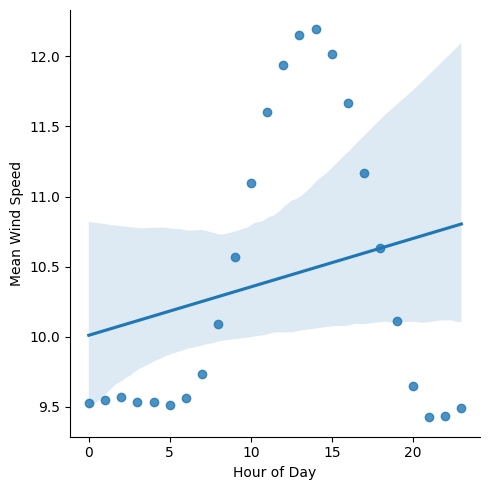

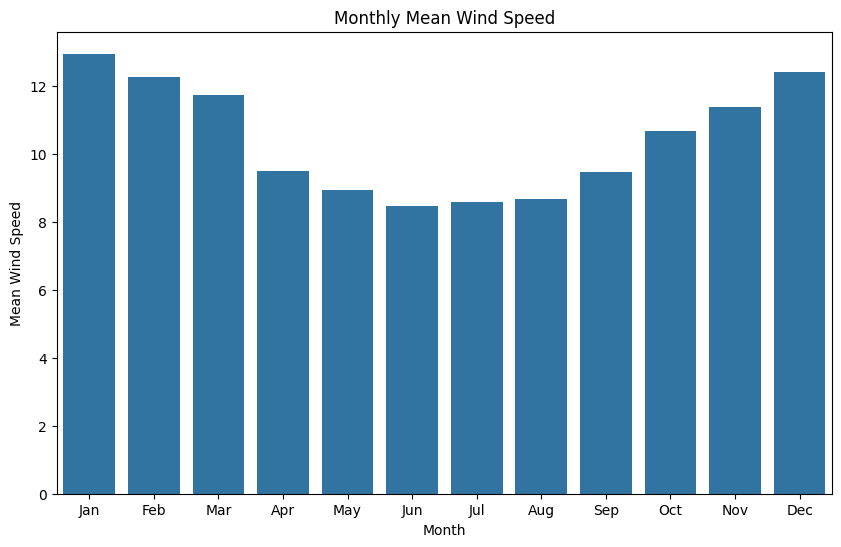

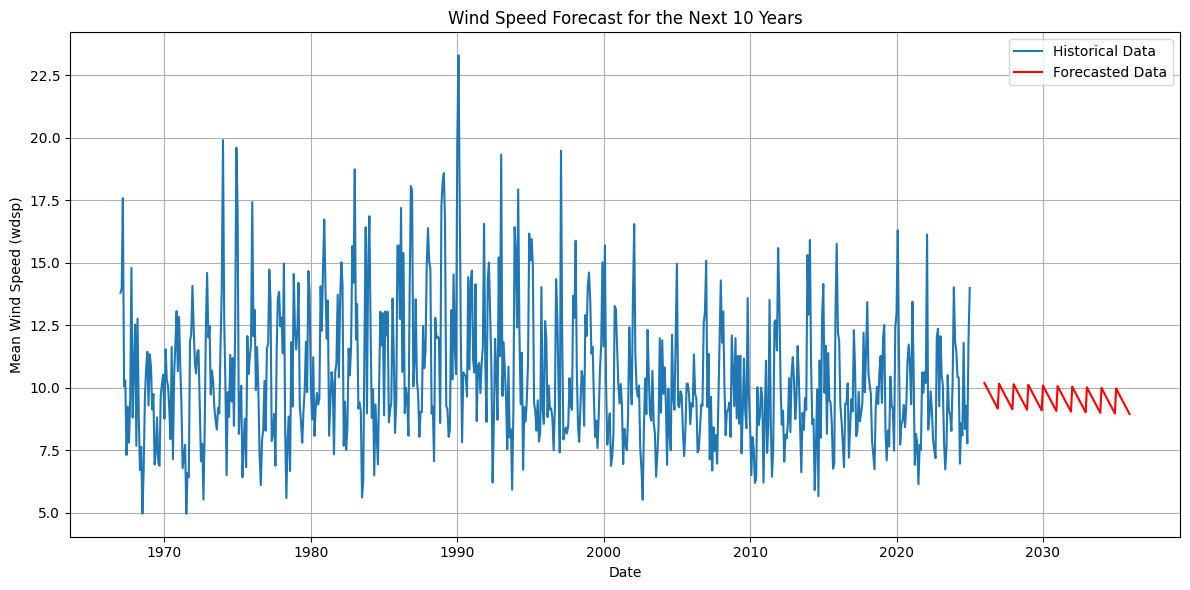

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Load the dataset
url = "https://cli.fusio.net/cli/climate_data/webdata/hly3723.csv"
df = pd.read_csv(url, skiprows=23, low_memory=False)

# Convert the 'date' column to datetime 
df['date'] = pd.to_datetime(df['date'], format="%d-%b-%Y %H:%M", errors='coerce', utc=True)

# Extracting the hour from the data
df['Hour'] = df['date'].dt.hour

# Extracting the month from the date 
df['Month'] = df['date'].dt.month

# Normalize the 'date' to remove time components
df['date'] = df['date'].dt.normalize()

# Convert 'wdsp' to numeric and handle errors
df['wdsp'] = pd.to_numeric(df['wdsp'], errors='coerce')

# Drop empty rows in 'wdsp' 
df = df.dropna(subset=['wdsp'])

# Set 'date' as the index
df.set_index('date', inplace=True)

# Group by hour and calculate mean wind speed
hourly_mean_wdsp = df.groupby('Hour')['wdsp'].mean().reset_index()

# Group by month and calculate mean wind speed
monthly_mean_wdsp = df.groupby('Month')['wdsp'].mean().reset_index()

# Plot hourly mean wind speed 
sns.lmplot(data=hourly_mean_wdsp, x='Hour', y='wdsp')
plt.xlabel("Hour of Day")
plt.ylabel("Mean Wind Speed")
plt.show()

# Plot monthly mean wind speed
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_mean_wdsp, x='Month', y='wdsp')
plt.title("Monthly Mean Wind Speed")
plt.xlabel("Month")
plt.ylabel("Mean Wind Speed")
plt.xticks(ticks=range(0, 12), labels=[
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])
plt.show()

# Prediction part

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Extracting year and month as features
df['year'] = df.index.year
df['month'] = df.index.month

# Group by year and month
monthly_mean_wdsp = df.groupby(['year', 'month'])['wdsp'].mean().reset_index()

# Prepare the features (X) and target variable (y)
X = monthly_mean_wdsp[['year', 'month']]
y = monthly_mean_wdsp['wdsp']

# Train-test split (optional)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and training the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Forecast for the next 10 years
future_years = np.arange(monthly_mean_wdsp['year'].max() + 1, monthly_mean_wdsp['year'].max() + 11)  # Start from the next year
future_months = np.arange(1, 13)
future_data = pd.DataFrame([(year, month) for year in future_years for month in future_months], columns=['year', 'month'])
forecast = model.predict(future_data)

# Create a proper date index for the future data
future_dates = pd.to_datetime(future_data['year'].astype(str) + '-' + future_data['month'].astype(str), format='%Y-%m')

# Create date index for historical data
historical_dates = pd.to_datetime(monthly_mean_wdsp['year'].astype(str) + '-' + monthly_mean_wdsp['month'].astype(str), format='%Y-%m')

# Plot the historical and forecasted data
plt.figure(figsize=(12, 6))
plt.plot(historical_dates, monthly_mean_wdsp['wdsp'], label='Historical Data')
plt.plot(future_dates, forecast, label='Forecasted Data', color='red')
plt.title("Wind Speed Forecast for the Next 10 Years")
plt.xlabel("Date")
plt.ylabel("Mean Wind Speed (wdsp)")
plt.legend()
plt.grid(True) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
